In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [20]:

BASE_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"

CSV_PATH = os.path.join(BASE_PATH, "csv")

JPEG_PATH = os.path.join(BASE_PATH, "jpeg")

print("CSV path exists:", os.path.exists(CSV_PATH))
print("JPEG path exists:", os.path.exists(JPEG_PATH))

CSV path exists: True
JPEG path exists: True


In [21]:

df_mass_train = pd.read_csv(os.path.join(CSV_PATH, "mass_case_description_train_set.csv"))

df_mass_test = pd.read_csv(os.path.join(CSV_PATH, "mass_case_description_test_set.csv"))

df_calc_train = pd.read_csv(os.path.join(CSV_PATH, "calc_case_description_train_set.csv"))

df_calc_test = pd.read_csv(os.path.join(CSV_PATH, "calc_case_description_test_set.csv"))

print("Mass train shape:", df_mass_train.shape)
print("Mass test shape:", df_mass_test.shape)
print("Calc train shape:", df_calc_train.shape)
print("Calc test shape:", df_calc_test.shape)

Mass train shape: (1318, 14)
Mass test shape: (378, 14)
Calc train shape: (1546, 14)
Calc test shape: (326, 14)


In [22]:

print("=== MASS TRAIN - Premières lignes ===")
df_mass_train.head()

=== MASS TRAIN - Premières lignes ===


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [23]:
# Afficher les noms de toutes les colonnes disponibles
print("Colonnes disponibles:")
print(df_mass_train.columns.tolist())

# Afficher des infos générales : type de chaque colonne, valeurs manquantes
df_mass_train.info()

Colonnes disponibles:
['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-nul

**Distribution bénin/malin**

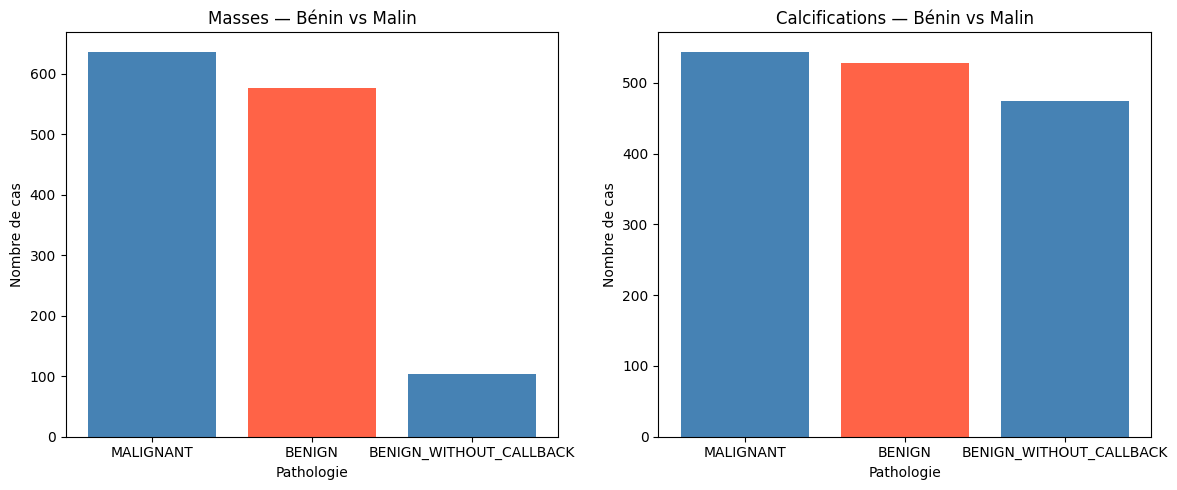

Masses: {'MALIGNANT': 637, 'BENIGN': 577, 'BENIGN_WITHOUT_CALLBACK': 104}
Calcifications: {'MALIGNANT': 544, 'BENIGN': 528, 'BENIGN_WITHOUT_CALLBACK': 474}


In [24]:
# Compter combien de cas bénins vs malins dans masses train
mass_counts = df_mass_train['pathology'].value_counts()

# Compter pour les calcifications 
calc_counts = df_calc_train['pathology'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Premier graphique : masses
axes[0].bar(
    mass_counts.index,   # labels : BENIGN, MALIGNANT
    mass_counts.values,  # valeurs : nombre de cas
    color=['steelblue', 'tomato']  # bleu = bénin, rouge = malin
)
axes[0].set_title("Masses — Bénin vs Malin")  # titre du graphique
axes[0].set_xlabel("Pathologie")               # label axe X
axes[0].set_ylabel("Nombre de cas")            # label axe Y

# Deuxième graphique : calcifications
axes[1].bar(
    calc_counts.index,
    calc_counts.values,
    color=['steelblue', 'tomato']
)
axes[1].set_title("Calcifications — Bénin vs Malin")
axes[1].set_xlabel("Pathologie")
axes[1].set_ylabel("Nombre de cas")

# Ajuster l'espacement entre les graphiques
plt.tight_layout()

# Afficher la figure
plt.show()

# Afficher les chiffres exacts
print("Masses:", mass_counts.to_dict())
print("Calcifications:", calc_counts.to_dict())

In [ ]:
# Étape 1 : voir ce qui existe vraiment dans le dossier
print("=== Contenu de /kaggle/input ===")
for dirname, subdirs, filenames in os.walk('/kaggle/input'):
  
    depth = dirname.replace('/kaggle/input', '').count(os.sep)
    if depth < 3:
        print('  ' * depth + os.path.basename(dirname) + '/')
    if filenames and depth < 3:
        for f in filenames[:3]:  
            print('  ' * (depth+1) + f)

=== Contenu de /kaggle/input ===
input/
  datasets/
    awsaf49/


In [26]:
# Étape 2 : voir ce que contient exactement la colonne image file path
print("Valeurs dans 'image file path':")
print(df_mass_train['image file path'].head(10).tolist())

Valeurs dans 'image file path':
['Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm', 'Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/000000.dcm', 'Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.347107867812656628709864319310977895697/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/000000.dcm', 'Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.272600286511817402806912403581910920939/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/000000.dcm', 'Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.174047308712169195014610267031196524486/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/000000.dcm', 'Mass-Training_P_00009_RIGHT_CC/1.3.6.1.4.1.9590.100.1.2.3480944362129807623127449997438181719

In [27]:
# Étape 3 : lister les vraies images disponibles dans jpeg/
jpeg_files = []
for dirname, _, filenames in os.walk(JPEG_PATH):
    for f in filenames:
        if f.endswith('.jpg') or f.endswith('.jpeg') or f.endswith('.png'):
            jpeg_files.append(os.path.join(dirname, f))

print(f"Nombre d'images trouvées : {len(jpeg_files)}")
print("Exemples de chemins réels:")
for f in jpeg_files[:5]:
    print(f)

Nombre d'images trouvées : 10237
Exemples de chemins réels:
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818/1-223.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/2-089.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/1-111.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.116437756113164247142539498550746659420/1-051.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.116437756113164247142539498550746659420/2-203.jpg


In [ ]:
# Combiner tous les datasets en un seul DataFrame
df_all = pd.concat([df_mass_train, df_mass_test, 
                    df_calc_train, df_calc_test], 
                    ignore_index=True)

# Nombre total de cas
print(f"Total cas: {len(df_all)}")

# Distribution globale bénin/malin
print("\nDistribution globale:")
print(df_all['pathology'].value_counts())

# Vérifier les valeurs manquantes
print("\nValeurs manquantes par colonne:")
print(df_all.isnull().sum())

Total cas: 3568

Distribution globale:
pathology
MALIGNANT                  1457
BENIGN                     1429
BENIGN_WITHOUT_CALLBACK     682
Name: count, dtype: int64

Valeurs manquantes par colonne:
patient_id                    0
breast_density             1872
left or right breast          0
image view                    0
abnormality id                0
abnormality type              0
mass shape                 1876
mass margins               1932
assessment                    0
pathology                     0
subtlety                      0
image file path               0
cropped image file path       0
ROI mask file path            0
breast density             1696
calc type                  1720
calc distribution          2135
dtype: int64


In [ ]:
# Construire un dictionnaire : id_unique → chemin jpeg réel

# Créer un mapping id → fichier jpeg
jpeg_map = {}
for filepath in jpeg_files:
    # Extraire l'identifiant (nom du dossier parent)
    folder_id = os.path.basename(os.path.dirname(filepath))
    if folder_id not in jpeg_map:
        jpeg_map[folder_id] = []
    jpeg_map[folder_id].append(filepath)

print(f"Nombre de dossiers uniques: {len(jpeg_map)}")
print("Exemple clé:", list(jpeg_map.keys())[0])

Nombre de dossiers uniques: 6774
Exemple clé: 1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818


In [ ]:
# Fonction pour trouver l'image jpeg correspondant à un chemin CSV
def find_jpeg(csv_path):
    parts = csv_path.split('/')
    
    for part in parts:
        if part in jpeg_map:
            return jpeg_map[part][0]  
    return None
=|
test_path = df_mass_train['image file path'].iloc[0]
result = find_jpeg(test_path)
print("Chemin CSV:", test_path)
print("Jpeg trouvé:", result)

Chemin CSV: Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
Jpeg trouvé: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg


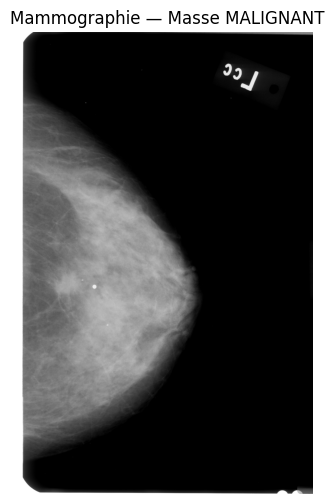

In [ ]:

if result:
    img = plt.imread(result)
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title("Mammographie — Masse MALIGNANT")
    plt.axis('off')
    plt.show()
else:
    print("Image non trouvée")